In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langchain_community.vectorstores import FAISS

In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader

c:\Users\ASUS\.conda\envs\graph-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LLM and Embedding model

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite-preview",
    temperature=0
)

In [6]:
from langchain_community.embeddings import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19544\960534211.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


In [7]:
loader = PyPDFLoader("attention.pdf")
chunks = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 100)
docs = text_splitter.split_documents(chunks)

In [8]:
db = FAISS.from_documents(docs, embeddings)

In [9]:
retriever = db.as_retriever(k=5)

Multi-Query Generation

In [10]:
from langchain_core.prompts import ChatPromptTemplate,MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

In [11]:
prompt = """You are a helpful assistant that generates multiple search queries based on a single input query. \n

Generate multiple search queries related to: {question} \n

Output (4 queries):"""

In [12]:
multi_prompt = ChatPromptTemplate.from_template(prompt)

In [13]:
generate_queries = (
    multi_prompt
    | llm
    | StrOutputParser()
    | RunnableLambda(lambda x: x.split("\n"))
)

Re-Ranking

In [14]:
def reciprocal_rank_fusion(results, k=60):

    fused_scores = {}
    doc_map = {}

    for docs in results:
        for rank, doc in enumerate(docs):

            doc_id = doc.page_content

            if doc_id not in fused_scores:
                fused_scores[doc_id] = 0
                doc_map[doc_id] = doc

            fused_scores[doc_id] += 1 / (rank + k) # reciprocal rank fusion formula

    reranked = sorted(
        fused_scores.keys(),
        key=lambda x: fused_scores[x],
        reverse=True
    )

    return [doc_map[x] for x in reranked]

Final Generation Chain

In [15]:

answer_prompt = ChatPromptTemplate.from_messages([
    ("system", "Answer the question based only on the context: {context}"),
    MessagesPlaceholder(variable_name="messages"),
    ("human", "{question}"),
])
answer_chain = (
    answer_prompt 
    | llm 
    | StrOutputParser()
)

Hallucination Check

In [16]:
hallucination_prompt = ChatPromptTemplate.from_template("""
You are a hallucination detection system.

Context:
{context}

Answer:
{answer}

Check if the answer is fully supported by the context.

Return:
- "GROUNDED" if supported
- "HALLUCINATED" if not supported

""")

In [17]:
hallucination_chain = (
    hallucination_prompt
    | llm
    | StrOutputParser()
)

Relevance Chain

In [18]:
from langchain_groq import ChatGroq
llm2=ChatGroq(model="llama-3.1-8b-instant")

In [19]:
relevance_prompt = ChatPromptTemplate.from_template("""
        You are a strict classifier.

        Determine whether the user's question can be answered
        using the provided document context.

        Question:
        {question}

        Context:
        {context}

        Answer ONLY:
        RELEVANT
        or
        NOT_RELEVANT
        """)

In [20]:
relevance_chain = (
    relevance_prompt
    | llm2
    | StrOutputParser()
)

In [21]:
def relevance_retrieval_chain(question):

        docs = retriever.invoke(question)

        context = "\n\n".join(
            doc.page_content for doc in docs[:3]
        )

        result = relevance_chain.invoke({
            "question": question,
            "context": context
        })

        return result

GRAPH WorkFlow

In [22]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage,AIMessage
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph,START,END
from langchain_core.documents import Document

In [23]:
class AgentState(TypedDict):
    question: str
    queries: List[str]
    context: List[Document]
    answer: str
    hallucination_status: str
    messages: Annotated[List[BaseMessage], add_messages]
    results: List[List[Document]] 

nodes

In [24]:
def multi_query_node(state: AgentState):

    queries = generate_queries.invoke({
        "question": state["question"]
    })

    return {
        "queries": queries
    }

In [25]:
def retrieve_node(state: AgentState):
    results = retriever.map().invoke(state["queries"])
    return {"results": results}

In [26]:
def reciprocal_rank_fusion_node(state: AgentState):

    fused_docs = reciprocal_rank_fusion(state["results"])
    return {"context": fused_docs}

In [27]:
def answer_node(state: AgentState):

    fused_docs = state["context"] 
    context_text = "\n\n".join(d.page_content for d in fused_docs)


    answer = answer_chain.invoke({
        "context": context_text,
        "question": state["question"],
        "messages": state["messages"]
    })
    return {"answer": answer,"messages": [HumanMessage(content=state["question"]),AIMessage(content=answer)]}

In [28]:
def hallucination_node(state: AgentState):

    context_text = "\n\n".join(
        doc.page_content for doc in state["context"]
    )

    status = hallucination_chain.invoke({
        "context": context_text,
        "answer": state["answer"]
    })

    return {
        "hallucination_status": status
    }

In [29]:
def fail_node(state: AgentState):

    return {
        "answer": (
            "I cannot answer this question based on the provided PDF. "
            "The information is not present in the document."
        )
    }

In [30]:
def relevance_node(state: AgentState):

        result = relevance_retrieval_chain(state["question"])

        if "NOT_RELEVANT" in result.strip().upper():
            return {
                "hallucination_status": "OUT_OF_SCOPE"
            }

        return {
            "hallucination_status": "RELEVANT"
        }

Routing

In [31]:
def route_after_relevance(state: AgentState):

    if state["hallucination_status"] == "OUT_OF_SCOPE":
        return "fail"

    return "generate_queries"

In [32]:
def route_after_hallucination(state: AgentState):

    if state["hallucination_status"] == "GROUNDED":
        return "end"

    return "fail"

Graph WorkFlow

In [33]:
graph = StateGraph(AgentState)

In [34]:
graph.add_node("generate_queries", multi_query_node)
graph.add_node("retrieve", retrieve_node)
graph.add_node("rerank", reciprocal_rank_fusion_node)
graph.add_node("answer", answer_node)
graph.add_node("hallucination", hallucination_node)
graph.add_node("fail", fail_node)
graph.add_node("relevance", relevance_node)

In [35]:
graph.set_entry_point("relevance")

In [36]:
graph.add_conditional_edges(
    "relevance",
    route_after_relevance,
    {
        "generate_queries": "generate_queries",
        "fail": "fail"
    }
)
graph.add_edge("generate_queries", "retrieve")
graph.add_edge("retrieve", "rerank")
graph.add_edge("rerank", "answer")
graph.add_edge("answer", "hallucination")
graph.add_conditional_edges(
    "hallucination",
    route_after_hallucination,
    {
        "fail": "fail",
        "end":END
    }
)
graph.add_edge("fail", END)

In [37]:
memory = MemorySaver()

app = graph.compile(checkpointer=memory)

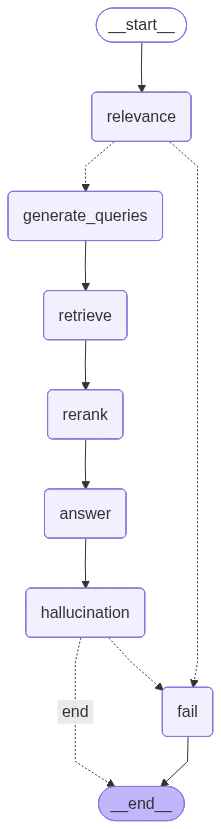

In [38]:
app

Inference

In [39]:
import uuid
def create_config():
    thread_id = str(uuid.uuid4())   # generate unique id
    config = {"configurable": {"thread_id": thread_id}}
    return config

In [40]:
config = create_config()

In [41]:
result = app.invoke({
    "question": "What is attention?",
    "queries": [],
    "context": [],
    "answer": "",
    "hallucination_status": "",
    "messages": []
},config=config)

In [42]:
print(result["answer"])

Based on the provided text, attention mechanisms are described as an integral part of sequence modeling and transduction models that allow for the modeling of dependencies without regard to their distance in the input or output sequences.

Additionally, the text notes that:
*   The Transformer model relies entirely on an attention mechanism to draw global dependencies between input and output, eschewing recurrence.
*   Self-attention can yield more interpretable models, as individual attention heads appear to learn to perform different tasks and exhibit behavior related to the syntactic and semantic structure of sentences.
*   Attention mechanisms can be used to follow long-distance dependencies (such as completing the phrase "making...more difficult").
*   Some attention heads may be involved in tasks such as anaphora resolution.


In [43]:
print(result["queries"])

['Output:', '', '1. What is the definition of attention in psychology?', '2. How does the attention mechanism work in artificial intelligence?', '3. What are the different types of attention in cognitive science?', '4. How does attention impact learning and memory?']


In [44]:
print(result["messages"])

[HumanMessage(content='What is attention?', additional_kwargs={}, response_metadata={}, id='d718c593-d00d-4bd9-be43-58746fefc166'), AIMessage(content='Based on the provided text, attention mechanisms are described as an integral part of sequence modeling and transduction models that allow for the modeling of dependencies without regard to their distance in the input or output sequences.\n\nAdditionally, the text notes that:\n*   The Transformer model relies entirely on an attention mechanism to draw global dependencies between input and output, eschewing recurrence.\n*   Self-attention can yield more interpretable models, as individual attention heads appear to learn to perform different tasks and exhibit behavior related to the syntactic and semantic structure of sentences.\n*   Attention mechanisms can be used to follow long-distance dependencies (such as completing the phrase "making...more difficult").\n*   Some attention heads may be involved in tasks such as anaphora resolution.'

In [45]:
result2 = app.invoke({
    "question": "What is the weather today?",
    "queries": [],
    "docs": [],
    "context": [],
    "answer": "",
    "hallucination_status": "",
    "messages": []
},config=config)

In [46]:
print(result2["answer"])

I cannot answer this question based on the provided PDF. The information is not present in the document.


In [134]:
result3 = app.invoke({
    "question": "Explain the structure of a transformer model.",

},config=config)

In [135]:
result3["answer"]

'The Transformer model follows an encoder-decoder architecture, relying entirely on stacked self-attention and point-wise, fully connected layers.\n\n**Overall Structure:**\n*   It has an encoder-decoder structure where the encoder maps an input sequence of symbol representations to a sequence of continuous representations.\n*   Given these continuous representations, the decoder then generates an output sequence of symbols one element at a time, being auto-regressive by consuming previously generated symbols as additional input.\n*   The model uses multi-head attention to counteract the reduced effective resolution due to averaging attention-weighted positions.\n\n**Encoder Structure:**\n*   The encoder is composed of a stack of N = 6 identical layers.\n*   Each encoder layer has two sub-layers:\n    1.  A multi-head self-attention mechanism.\n    2.  A simple, position-wise fully connected feed-forward network.\n*   Residual connections are employed around each of these two sub-layer